In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/Folds5x2_pp.xlsx", sheet_name=0)

In [3]:
print(df.shape)
df.head()

(9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) i.

The dataset (Sheet 1) has **9568 rows** and **5 columns**.

**Rows:** Each row is one observation of the power plant running at full load, recorded as **hourly averages** over 6 years (2006–2011).

**Columns:**

| Column | Meaning | Unit | Role |
|---|---|---|---|
| AT | Ambient Temperature | °C | Predictor |
| V  | Exhaust Vacuum | cm Hg | Predictor |
| AP | Ambient Pressure | millibar | Predictor |
| RH | Relative Humidity | % | Predictor |
| PE | Net hourly electrical energy output | MW | Response |

The first four columns (AT, V, AP, RH) are the independent variables (predictors), and PE is the dependent variable (response) that we want to predict.


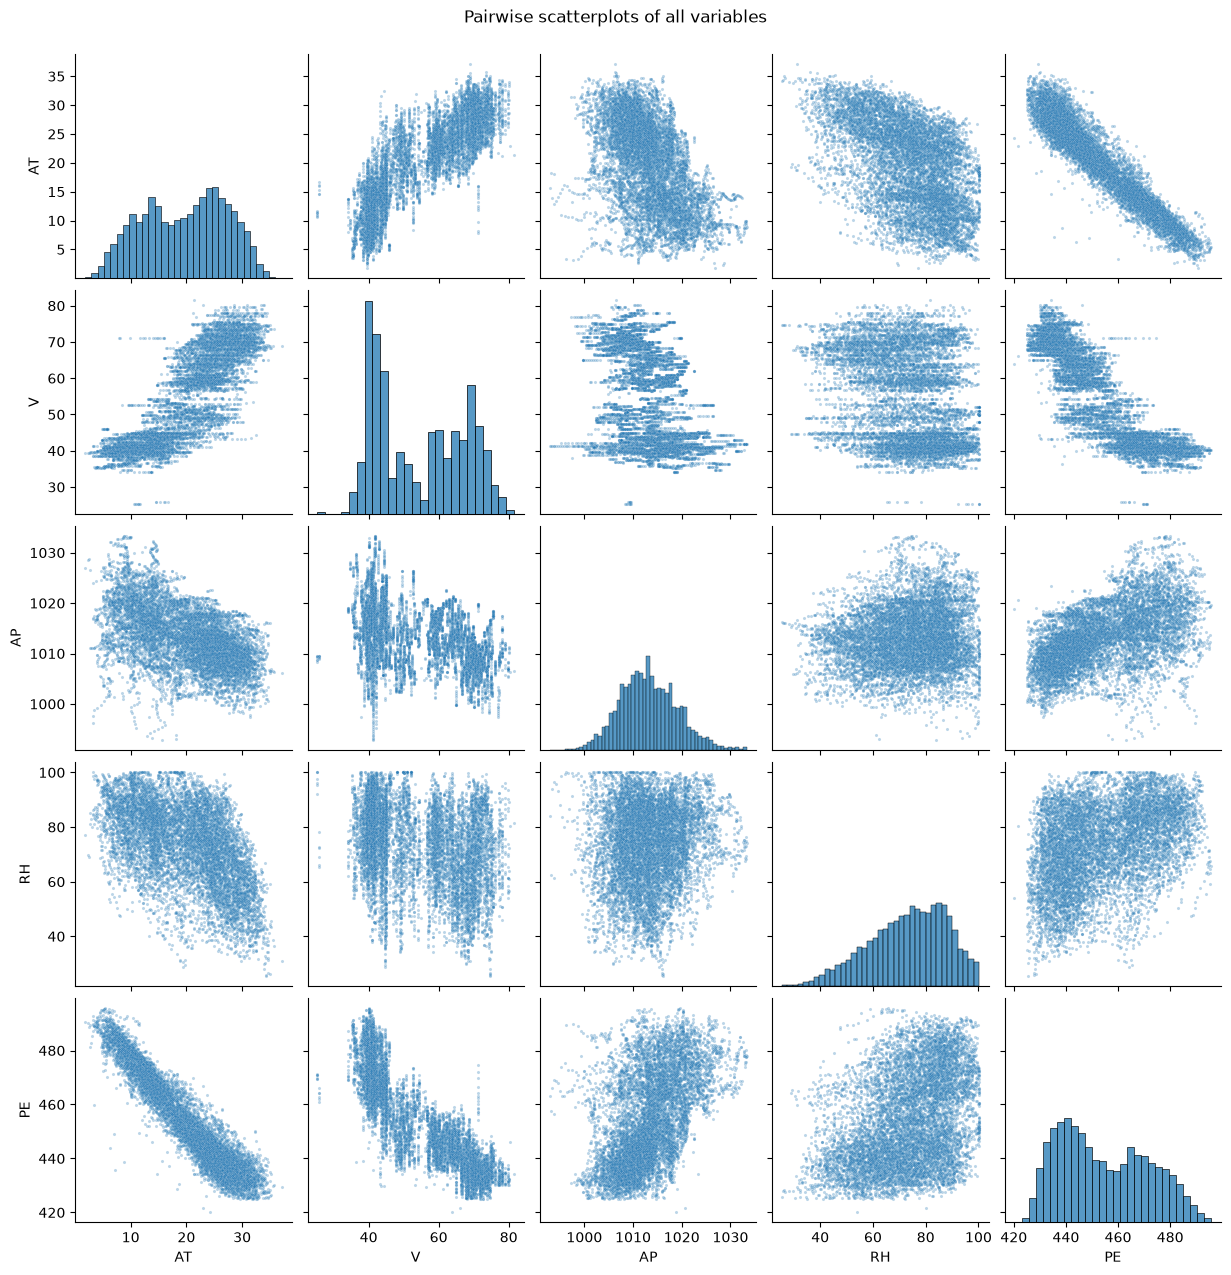

In [4]:
sns.pairplot(df, plot_kws={"s": 5, "alpha": 0.3})
plt.suptitle("Pairwise scatterplots of all variables", y=1.02)
plt.show()

### (b) ii. Findings

AT and PE have a strong negative relationship (r = -0.95). The points are packed into a narrow line, so when the temperature goes up, the energy output goes down. AT seems to be the best single predictor.

V and PE are also negatively related (r = -0.87), but the points are more spread out than for AT.

AP has a moderate positive relationship with PE (r = 0.52), and RH has a weak positive one (r = 0.39). Both plots are pretty noisy.

Among the predictors, AT and V are highly correlated (r = 0.84). This could cause collinearity problems in the multiple regression later.

From the histograms, AP looks close to normal, RH is skewed left and stops around 100%, and AT has two peaks, maybe because of seasons. V has several peaks, and its values seem to cluster at certain levels.

In [5]:
summary = pd.DataFrame({
    "Mean":   df.mean(),
    "Median": df.median(),
    "Min":    df.min(),
    "Max":    df.max(),
    "Range":  df.max() - df.min(),
    "Q1":     df.quantile(0.25),
    "Q3":     df.quantile(0.75),
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.round(2)

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


### (b) iii. Summary

AP barely changes. Its IQR is only about 8 millibar, while its mean is about 1013. PE goes from about 420 to 496 MW, with an IQR of about 29.

For RH, the mean (73.3) is lower than the median (75.0), which matches its left skew. V and PE have means a bit higher than their medians, so they are slightly right-skewed.

The variables are on very different scales (AP is around 1000, while RH is around 70), so the features should be normalized before running KNN.